# Random Forest


This notebook trains an optimized, regularized **Random Forest Classifier** model on the tabular audio features extracted from the dataset.

### Overview
- **Input**: Tabular feature data (`train.csv`, `valid.csv`, `test.csv`) containing 31 extracted acoustic features.
- **Preprocessing**: Missing values are imputed using the median.
- **Model**: Regularized `RandomForestClassifier` with constrained tree depth (`max_depth=16`), minimum leaf samples (`min_samples_leaf=3`), and balanced subsampling to prevent severe overfitting on the train set.
- **Ensemble Readiness**: Exports validation and test probability matrices (`rf_val_probs.npy`, `rf_test_probs.npy`).

### Usage on Kaggle
If running on Kaggle, ensure the dataset is mounted and update the `DATA_DIR` path to point to `../input/song-genre-classification/`.

In [1]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = Path.cwd().parents[1]  
DATA_DIR = BASE_DIR

TRAIN_CSV = DATA_DIR / "train.csv"
VAL_CSV = DATA_DIR / "valid.csv"
TEST_CSV = DATA_DIR / "test.csv"

# Fallback check for csvs/CSVs location
if not TRAIN_CSV.exists() and (DATA_DIR / "csvs" / "CSVs" / "train.csv").exists():
    TRAIN_CSV = DATA_DIR / "csvs" / "CSVs" / "train.csv"
    VAL_CSV = DATA_DIR / "csvs" / "CSVs" / "valid.csv"
    TEST_CSV = DATA_DIR / "csvs" / "CSVs" / "test.csv"
elif not TRAIN_CSV.exists() and (DATA_DIR / "csvs" / "train.csv").exists():
    TRAIN_CSV = DATA_DIR / "csvs" / "train.csv"
    VAL_CSV = DATA_DIR / "csvs" / "valid.csv"
    TEST_CSV = DATA_DIR / "csvs" / "test.csv"

MODELS_DIR = BASE_DIR / "models" / "features"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_DIR / "randomforest.joblib"

In [2]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train shape:", train_df.shape)
print("Valid shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain class distribution:")
print(train_df["Genre"].value_counts(normalize=True))

print("\nValid class distribution:")
print(val_df["Genre"].value_counts(normalize=True))

print("\nTest class distribution:")
print(test_df["Genre"].value_counts(normalize=True))

Train shape: (12208, 33)
Valid shape: (2442, 33)
Test shape: (1610, 33)

Train class distribution:
Genre
edm        0.132126
rock       0.127867
pop        0.118037
kpop       0.117218
country    0.115908
r&b        0.115498
hiphop     0.108699
lofi       0.106078
jazz       0.058568
Name: proportion, dtype: float64

Valid class distribution:
Genre
edm        0.132269
rock       0.131040
pop        0.119165
r&b        0.114251
kpop       0.114251
country    0.113022
lofi       0.111384
hiphop     0.105651
jazz       0.058968
Name: proportion, dtype: float64

Test class distribution:
Genre
edm        0.136646
pop        0.122360
rock       0.120497
kpop       0.120497
country    0.118634
lofi       0.107453
r&b        0.107453
hiphop     0.106832
jazz       0.059627
Name: proportion, dtype: float64


In [3]:
TARGET_COL = "Genre"
IGNORE_COLS = [TARGET_COL, "Filename"]

feature_cols = [c for c in train_df.columns if c not in IGNORE_COLS]

X_train = train_df[feature_cols]
y_train = train_df[TARGET_COL]

X_val = val_df[feature_cols]
y_val = val_df[TARGET_COL]

X_test = test_df[feature_cols]
y_test = test_df[TARGET_COL]

print("Number of features:", len(feature_cols))
print("First few feature columns:", feature_cols[:10])

Number of features: 31
First few feature columns: ['Zero_Crossing_Rate', 'RMS_Energy', 'Amplitude_Envelope_Mean', 'Energy_Entropy', 'Mean_Amplitude', 'Variance_Amplitude', 'Skewness_Amplitude', 'Kurtosis_Amplitude', 'Peak_to_Peak_Amplitude', 'Spectral_Centroid']


In [4]:
numeric_cols = feature_cols

# Regularized Random Forest to prevent tree memorization and train set overfitting
rf_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(
            n_estimators=400,
            max_depth=16,
            min_samples_split=6,
            min_samples_leaf=3,
            max_features="sqrt",
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=42,
        )),
    ]
)

print("Training Regularized RandomForestClassifier on train split...")
rf_pipeline.fit(X_train, y_train)
print("Training complete.")

In [5]:
val_preds = rf_pipeline.predict(X_val)
val_probs = rf_pipeline.predict_proba(X_val)
val_acc = accuracy_score(y_val, val_preds)

print(f"Validation accuracy: {val_acc:.4f}")
print("\nValidation classification report:")
print(classification_report(y_val, val_preds))

print("Validation confusion matrix:")
print(confusion_matrix(y_val, val_preds))

In [6]:
test_preds = rf_pipeline.predict(X_test)
test_probs = rf_pipeline.predict_proba(X_test)
test_acc = accuracy_score(y_test, test_preds)

print(f"Test accuracy: {test_acc:.4f}")
print("\nTest classification report:")
print(classification_report(y_test, test_preds))

print("Test confusion matrix:")
print(confusion_matrix(y_test, test_preds))

# Export validation and test probability distributions for ensembling
np.save(MODELS_DIR / "rf_val_probs.npy", val_probs)
np.save(MODELS_DIR / "rf_test_probs.npy", test_probs)
np.save(MODELS_DIR / "rf_classes.npy", rf_pipeline.classes_)
print(f"\nSaved Random Forest predicted probabilities to {MODELS_DIR}")

In [7]:
joblib.dump(rf_pipeline, MODEL_PATH)
print(f"Saved Random Forest feature model to {MODEL_PATH}")

Saved Random Forest feature model to f:\Python\Song Genre Classification\models\features\randomforest.joblib


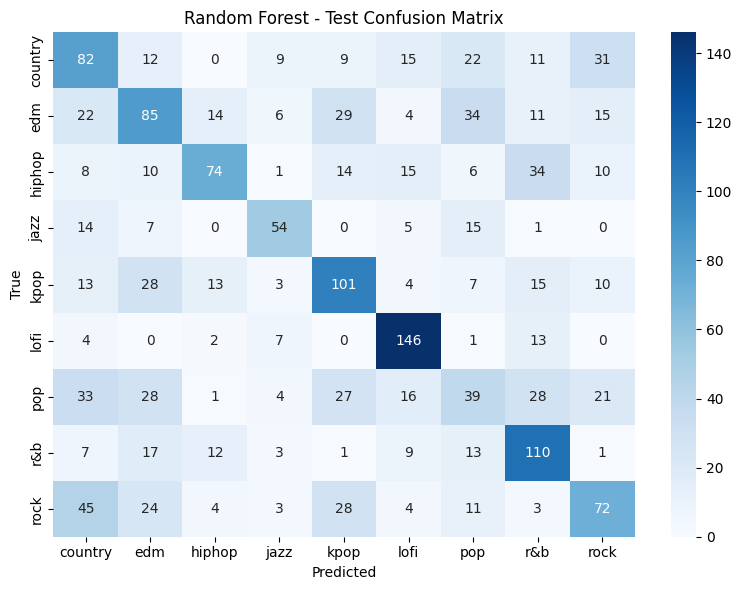

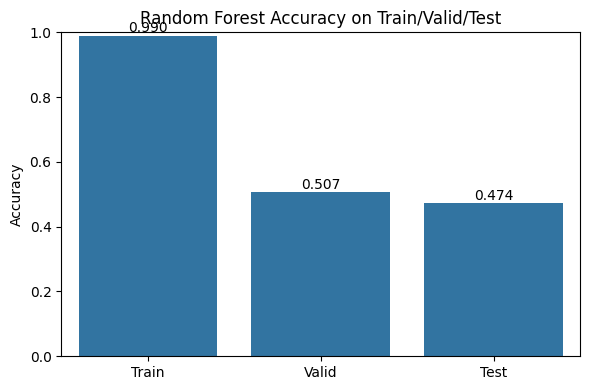

In [8]:
cm = confusion_matrix(y_test, test_preds)
labels = sorted(y_test.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest - Test Confusion Matrix")
plt.tight_layout()
plt.show()

# Accuracy bar chart for train/valid/test
train_acc = accuracy_score(y_train, rf_pipeline.predict(X_train))

plt.figure(figsize=(6, 4))
sets = ["Train", "Valid", "Test"]
accs = [train_acc, val_acc, test_acc]

sns.barplot(x=sets, y=accs)
plt.ylim(0, 1)
for i, v in enumerate(accs):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy on Train/Valid/Test")
plt.tight_layout()
plt.show()